In [164]:
import warnings
import os
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import seaborn as sns
import re

# Analysis of results

## Calculate mean of the iterations of each parameter set 

In [165]:
# Prepare dataFrame to store mean values
df_output = pd.DataFrame(columns=["CAR_DRIVER", "CAR_PASSENGER", "BIKE", "BUS_TRAM", "TRAIN", "WALK"])

df_output

,CAR_DRIVER,CAR_PASSENGER,BIKE,BUS_TRAM,TRAIN,WALK


In [ ]:
warnings.filterwarnings("ignore")

folder_path = 'output/iterations'


folder_path = 'output/iterations'

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split(r'(\d+)', s)]

# Retrieve and sort the filenames
filenames = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
filenames.sort(key=natural_sort_key)

for filename in filenames:
    #if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        
        # Calculate the mean of each column
        mean_values = df.mean()*100
        
        #print(mean_values)
                        
        # Append the mean values to the new DataFrame       
        df_output.loc[len(df_output)] = mean_values
        
# Enable warnings again
warnings.filterwarnings("default")

In [167]:
df_output

,CAR_DRIVER,CAR_PASSENGER,BIKE,BUS_TRAM,TRAIN,WALK
0,9.016108,14.156059,58.227746,12.102370,6.115936,0.381782
1,9.011267,14.149980,58.241274,12.044894,5.950501,0.602083
2,9.008120,14.058831,58.124360,11.965149,5.411811,1.431730
3,8.824638,13.852569,57.544815,11.718866,4.084032,3.975079
4,8.325054,13.141505,54.908165,11.125417,2.711554,9.788305
...,...,...,...,...,...,...
61,6.838296,10.853449,41.557090,8.826709,7.492207,24.432249
62,6.296351,10.229123,39.222639,8.033775,14.558120,21.659992
63,6.033259,9.975337,38.514936,7.837492,18.955620,18.683356
64,5.985519,9.933192,38.451678,7.760947,20.442835,17.425829


## Link means with parameter set for evaluation

In [168]:
# read parameters that were run
df_input = pd.read_csv('data/parametersets_to_run.csv')

# check that everything matches
print(df_output.shape[0])
print(df_input.shape[0])
print(df_output.shape[0] == df_input.shape[0])

# put parameters and results together
df = pd.concat([df_input, df_output], axis=1)

66
66
True


In [169]:
df

,alphaWalk,alphaBike,alphaCarDriver,alphaCarPassenger,alphaBus,alphaTrain,betaTimeWalk,betaTimeBike,betaTimeCarDriver,betaTimeCarPassenger,...,used_parameter_value,carCostKm,ptCostKm,ptBaseCost,CAR_DRIVER,CAR_PASSENGER,BIKE,BUS_TRAM,TRAIN,WALK
0,-10.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-10.0,0.25,0.187,1.08,9.016108,14.156059,58.227746,12.102370,6.115936,0.381782
1,-8.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-8.0,0.25,0.187,1.08,9.011267,14.149980,58.241274,12.044894,5.950501,0.602083
2,-6.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-6.0,0.25,0.187,1.08,9.008120,14.058831,58.124360,11.965149,5.411811,1.431730
3,-4.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-4.0,0.25,0.187,1.08,8.824638,13.852569,57.544815,11.718866,4.084032,3.975079
4,-2.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-2.0,0.25,0.187,1.08,8.325054,13.141505,54.908165,11.125417,2.711554,9.788305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,0.0,0.0,0.0,0.0,0.0,2.0,-0.04,-0.03,-0.02,-0.02,...,2.0,0.25,0.187,1.08,6.838296,10.853449,41.557090,8.826709,7.492207,24.432249
62,0.0,0.0,0.0,0.0,0.0,4.0,-0.04,-0.03,-0.02,-0.02,...,4.0,0.25,0.187,1.08,6.296351,10.229123,39.222639,8.033775,14.558120,21.659992
63,0.0,0.0,0.0,0.0,0.0,6.0,-0.04,-0.03,-0.02,-0.02,...,6.0,0.25,0.187,1.08,6.033259,9.975337,38.514936,7.837492,18.955620,18.683356
64,0.0,0.0,0.0,0.0,0.0,8.0,-0.04,-0.03,-0.02,-0.02,...,8.0,0.25,0.187,1.08,5.985519,9.933192,38.451678,7.760947,20.442835,17.425829


# Plot linear regressions

In [170]:
df

,alphaWalk,alphaBike,alphaCarDriver,alphaCarPassenger,alphaBus,alphaTrain,betaTimeWalk,betaTimeBike,betaTimeCarDriver,betaTimeCarPassenger,...,used_parameter_value,carCostKm,ptCostKm,ptBaseCost,CAR_DRIVER,CAR_PASSENGER,BIKE,BUS_TRAM,TRAIN,WALK
0,-10.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-10.0,0.25,0.187,1.08,9.016108,14.156059,58.227746,12.102370,6.115936,0.381782
1,-8.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-8.0,0.25,0.187,1.08,9.011267,14.149980,58.241274,12.044894,5.950501,0.602083
2,-6.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-6.0,0.25,0.187,1.08,9.008120,14.058831,58.124360,11.965149,5.411811,1.431730
3,-4.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-4.0,0.25,0.187,1.08,8.824638,13.852569,57.544815,11.718866,4.084032,3.975079
4,-2.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-2.0,0.25,0.187,1.08,8.325054,13.141505,54.908165,11.125417,2.711554,9.788305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,0.0,0.0,0.0,0.0,0.0,2.0,-0.04,-0.03,-0.02,-0.02,...,2.0,0.25,0.187,1.08,6.838296,10.853449,41.557090,8.826709,7.492207,24.432249
62,0.0,0.0,0.0,0.0,0.0,4.0,-0.04,-0.03,-0.02,-0.02,...,4.0,0.25,0.187,1.08,6.296351,10.229123,39.222639,8.033775,14.558120,21.659992
63,0.0,0.0,0.0,0.0,0.0,6.0,-0.04,-0.03,-0.02,-0.02,...,6.0,0.25,0.187,1.08,6.033259,9.975337,38.514936,7.837492,18.955620,18.683356
64,0.0,0.0,0.0,0.0,0.0,8.0,-0.04,-0.03,-0.02,-0.02,...,8.0,0.25,0.187,1.08,5.985519,9.933192,38.451678,7.760947,20.442835,17.425829


In [171]:
threshold_slope_abs = 0.000 # possibility to filter out parameters without much impact

Name: alphaWalk
col: WALK
col: BIKE
col: BUS_TRAM
col: TRAIN
col: CAR_DRIVER
col: CAR_PASSENGER
Name: alphaBike
col: WALK
col: BIKE
col: BUS_TRAM
col: TRAIN
col: CAR_DRIVER
col: CAR_PASSENGER
Name: alphaCarDriver
col: WALK
col: BIKE
col: BUS_TRAM
col: TRAIN
col: CAR_DRIVER
col: CAR_PASSENGER
Name: alphaCarPassenger
col: WALK
col: BIKE
col: BUS_TRAM
col: TRAIN
col: CAR_DRIVER
col: CAR_PASSENGER
Name: alphaBus
col: WALK
col: BIKE
col: BUS_TRAM
col: TRAIN
col: CAR_DRIVER
col: CAR_PASSENGER
Name: alphaTrain
col: WALK
col: BIKE
col: BUS_TRAM
col: TRAIN
col: CAR_DRIVER
col: CAR_PASSENGER


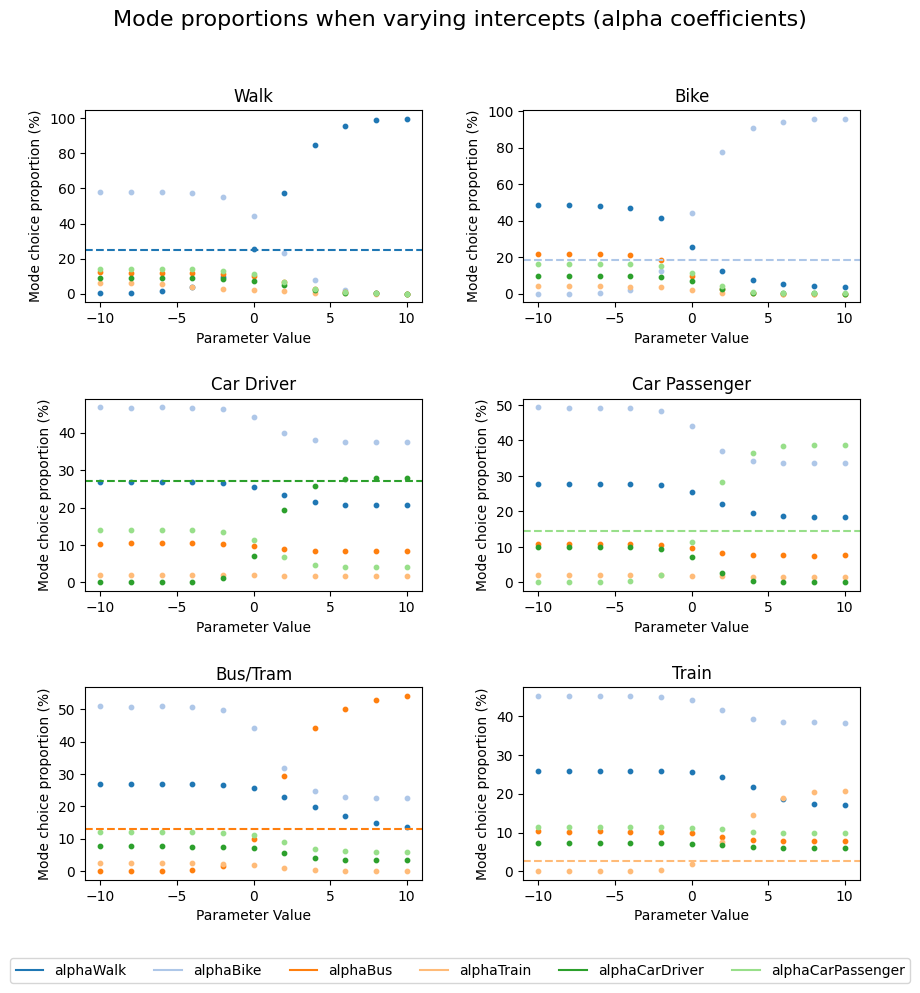

In [194]:
# Initialize an empty list to store parameter names with slope > 0.1
params_with_slope = []

groups = df.groupby('used_parameter_label')

output_cols = ['WALK', 'BIKE', 'BUS_TRAM', 'TRAIN', 'CAR_DRIVER', 'CAR_PASSENGER']

ground_truth = lookup = {"Walk": 24.7, "Bike" : 18.3, "Bus" : 12.9, "Train": 2.6, "CarDriver": 27.2,"CarPassenger": 14.4}


lookup = {"Walk": 'Walk', "Bike" : 'Bike', "Bus" : 'Bus/Tram', "Train": 'Train', "CarDriver": 'Car Driver',"CarPassenger": 'Car Passenger'}
lookup_copy = {"Walk": 'WALK', "Bike" : 'BIKE', "Bus" : 'BUS_TRAM', "Train": 'TRAIN', "CarDriver": 'CAR_DRIVER',"CarPassenger": 'CAR_PASSENGER'}
lookup_inv = {'WALK':"alphaWalk",  'BIKE': "alphaBike" , 'BUS_TRAM': "alphaBus" , 'TRAIN' :"alphaTrain" , 'CAR_DRIVER' : "alphaCarDriver" ,'CAR_PASSENGER':"alphaCarPassenger" }
# Loop over each group and calculate the slope for each parameter
for name, group in groups:
    for col in output_cols:
        # Calculate the slope for this parameter and output column
        slope, intercept = np.polyfit(group['used_parameter_value'], group[col], 1)
    
        # Check if the absolute value of the slope is greater than 0.1
        if abs(slope) > threshold_slope_abs and lookup[name[5:]] == col:
            #print(lookup[name[5:]])
            #print(col)
            #Add the parameter name to the list
            params_with_slope.append(name)
            break  # Only need to add the parameter name once

# Filter the dataframe to only include rows with parameter names in params_with_slope
df_filtered = df#  df[df['used_parameter_label'].isin(params_with_slope)]



# Group the filtered data by parameter name
groups_filtered = df_filtered.groupby('used_parameter_label')

# Create a new figure with a 3x2 grid of subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))

# Initialize a dictionary to store the colors for each group
colors = {}

df['used_parameter_label'] = pd.Categorical(
    df['used_parameter_label'], 
    categories=['alphaWalk','alphaBike','alphaCarDriver','alphaCarPassenger','alphaBus','alphaTrain'], 
    ordered=True
)

# Loop over each output column and plot the data in a separate subplot
for outer_idx, (name, group) in enumerate(df.groupby('used_parameter_label')) :
    print(f"Name: {name}")
    # Get the axis object for this subplot
    ax = axs[outer_idx // 2, outer_idx % 2]
    #print(ax)
    
    j = 0
    # Loop over each group and plot the data for this output column
    for i, col in enumerate(output_cols):
        #print(group[col])
        print(f"col: {col}")
       
        #print(f"Lookup: {lookup[col[5:]]}")
        #print(group[lookup[name[5:]]])
        # Extract the x and y values for this group and output column
        x = group['used_parameter_value']
        y = group[col]# group[col]
        
        # Assign a color to this group based on its name
        if col not in colors:
            colors[col] = plt.cm.tab20(j)
        
        # Plot the data points
        slope, intercept = np.polyfit(x, y, 1)
        regression_line = intercept + slope * x
        #ax.plot(x, regression_line, label=name, color=colors[name])
        
        
        ax.scatter(x, y, label=col, color=colors[col], alpha=1, s = 10, marker='o')
        
        j=j+1
    
    # Set the title for this subplot to the name of the output column
    ax.set_title(lookup[name[5:]])
    
    # Set the axis labels for this subplot
    ax.set_xlabel('Parameter Value')
    ax.set_ylabel('Mode choice proportion (%)')
    ax.axhline(y=ground_truth[name[5:]], color=colors[lookup_copy[name[5:]]], label='Threshold',ls='--')
    
    #ax.set_xlim(0, 1)
    #ax.set_ylim(0, 1)
    
# Create a legend for the whole figure
handles, labels = [], []
for name, group in groups_filtered:
    for col in output_cols:
        # if name in params_with_slope:
            # Check if the parameter name has already been added to the labels list
        if lookup_inv[col] not in labels:
            # Add a handle to the handles list for this parameter name
            handle = plt.plot([], [], label=lookup_inv[col], color=colors[col])[0]
            handles.append(handle)
            labels.append(lookup_inv[col])

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=len(labels))

# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.3, hspace=0.5)

# Title
fig.suptitle('Mode proportions when varying intercepts (alpha coefficients)', fontsize=16)

# Save
plt.savefig('plot_slopes_'+str(threshold_slope_abs)+'.pdf', dpi=300, bbox_inches='tight',format="pdf")

# Show the plot
plt.show()

In [173]:
df

,alphaWalk,alphaBike,alphaCarDriver,alphaCarPassenger,alphaBus,alphaTrain,betaTimeWalk,betaTimeBike,betaTimeCarDriver,betaTimeCarPassenger,...,used_parameter_value,carCostKm,ptCostKm,ptBaseCost,CAR_DRIVER,CAR_PASSENGER,BIKE,BUS_TRAM,TRAIN,WALK
0,-10.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-10.0,0.25,0.187,1.08,9.016108,14.156059,58.227746,12.102370,6.115936,0.381782
1,-8.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-8.0,0.25,0.187,1.08,9.011267,14.149980,58.241274,12.044894,5.950501,0.602083
2,-6.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-6.0,0.25,0.187,1.08,9.008120,14.058831,58.124360,11.965149,5.411811,1.431730
3,-4.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-4.0,0.25,0.187,1.08,8.824638,13.852569,57.544815,11.718866,4.084032,3.975079
4,-2.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-2.0,0.25,0.187,1.08,8.325054,13.141505,54.908165,11.125417,2.711554,9.788305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,0.0,0.0,0.0,0.0,0.0,2.0,-0.04,-0.03,-0.02,-0.02,...,2.0,0.25,0.187,1.08,6.838296,10.853449,41.557090,8.826709,7.492207,24.432249
62,0.0,0.0,0.0,0.0,0.0,4.0,-0.04,-0.03,-0.02,-0.02,...,4.0,0.25,0.187,1.08,6.296351,10.229123,39.222639,8.033775,14.558120,21.659992
63,0.0,0.0,0.0,0.0,0.0,6.0,-0.04,-0.03,-0.02,-0.02,...,6.0,0.25,0.187,1.08,6.033259,9.975337,38.514936,7.837492,18.955620,18.683356
64,0.0,0.0,0.0,0.0,0.0,8.0,-0.04,-0.03,-0.02,-0.02,...,8.0,0.25,0.187,1.08,5.985519,9.933192,38.451678,7.760947,20.442835,17.425829


In [174]:
df_filtered

,alphaWalk,alphaBike,alphaCarDriver,alphaCarPassenger,alphaBus,alphaTrain,betaTimeWalk,betaTimeBike,betaTimeCarDriver,betaTimeCarPassenger,...,used_parameter_value,carCostKm,ptCostKm,ptBaseCost,CAR_DRIVER,CAR_PASSENGER,BIKE,BUS_TRAM,TRAIN,WALK
0,-10.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-10.0,0.25,0.187,1.08,9.016108,14.156059,58.227746,12.102370,6.115936,0.381782
1,-8.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-8.0,0.25,0.187,1.08,9.011267,14.149980,58.241274,12.044894,5.950501,0.602083
2,-6.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-6.0,0.25,0.187,1.08,9.008120,14.058831,58.124360,11.965149,5.411811,1.431730
3,-4.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-4.0,0.25,0.187,1.08,8.824638,13.852569,57.544815,11.718866,4.084032,3.975079
4,-2.0,0.0,0.0,0.0,0.0,0.0,-0.04,-0.03,-0.02,-0.02,...,-2.0,0.25,0.187,1.08,8.325054,13.141505,54.908165,11.125417,2.711554,9.788305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,0.0,0.0,0.0,0.0,0.0,2.0,-0.04,-0.03,-0.02,-0.02,...,2.0,0.25,0.187,1.08,6.838296,10.853449,41.557090,8.826709,7.492207,24.432249
62,0.0,0.0,0.0,0.0,0.0,4.0,-0.04,-0.03,-0.02,-0.02,...,4.0,0.25,0.187,1.08,6.296351,10.229123,39.222639,8.033775,14.558120,21.659992
63,0.0,0.0,0.0,0.0,0.0,6.0,-0.04,-0.03,-0.02,-0.02,...,6.0,0.25,0.187,1.08,6.033259,9.975337,38.514936,7.837492,18.955620,18.683356
64,0.0,0.0,0.0,0.0,0.0,8.0,-0.04,-0.03,-0.02,-0.02,...,8.0,0.25,0.187,1.08,5.985519,9.933192,38.451678,7.760947,20.442835,17.425829
